# Per-site new peaks — where SVs / non-SNP variants beat SNPs, garden by garden

The multi-trait (JOINT) and variance-partition analyses find the non-SNP layer **redundant** with
SNPs (passengers): a garden-specific peak gets diluted across a 30-df meta and averages to ~0 in
the polygenic partition. **Per-garden (single-site) is the right lens** — and there, SVs/indels do
surface real peaks the SNP scan misses.

"**New peak**" = a clq0.9 block **significant in the class (SV / non-SNP) scan whose SNPs were
NOT significant in the SNP-only scan** — the plain class-unique-hit definition, computed at **both
FDR and Bonferroni**. (We also record the −log10p `gap` vs the best SNP in the block as a column,
so near-threshold "straddle" cases can be told apart if wanted, but it is **not** a filter.) They
**recur across independent gardens** (e.g. `AT5G04170`/CML50 as an SV peak in many gardens) —
recurrence at the same locus across gardens is signal, not FDR noise. Gardens are **ordered and
coloured by bio1** (annual mean temperature, cold→hot) to see whether the new peaks cluster by
climate. Caveats kept: FDR tier is looser, no genome-wide GO enrichment (`go_enrichment_nonsnp.py`);
candidate local-adaptation / incomplete-SNP-tagging loci, not a confirmed adaptive layer. No chart
titles per repo convention.

In [1]:

import os, sys
import numpy as np, pandas as pd
from scipy import stats
import matplotlib as mpl, matplotlib.pyplot as plt
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
sys.path.insert(0, "analysis/grenenet_gea")
import lib
DIR = "analysis/grenenet_gea/varexp"
CHROM_ORDER = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]
CCOL = {"Chr1": "#3A5A98", "Chr2": "#AEBDD6", "Chr3": "#3A5A98", "Chr4": "#AEBDD6", "Chr5": "#3A5A98"}
ACC, SNPG = "#E07A5F", "#B7C0CC"
# chromosome-alternating palettes for the mirror/zoom: SNP grey, non-SNP/SV green
SNP_GREY = {"Chr1": "#868E96", "Chr2": "#CED4DA", "Chr3": "#868E96", "Chr4": "#CED4DA", "Chr5": "#868E96"}
NS_GREEN = {"Chr1": "#1B5E20", "Chr2": "#66BB6A", "Chr3": "#1B5E20", "Chr4": "#66BB6A", "Chr5": "#1B5E20"}
GREEN_DK = "#1B5E20"
BIO_CMAP = plt.cm.coolwarm       # cold = blue, hot = red

def load(name):
    d = np.load(f"{DIR}/class_gwas_{name}.npz", allow_pickle=True)
    chrom = np.array([c.replace("chr", "Chr") for c in d["chrom"]]); pos = d["pos"].astype(np.int64)
    blk = lib.assign_clq_blocks(chrom, pos, r2=0.9)
    return dict(chrom=chrom, pos=pos, Z=d["Z"], sites=list(d["sites"]), blk=blk)

SNP, NS, SV = load("snp"), load("nonsnp"), load("sv")   # SNP block-assign is the slow step (~1 min)
sites = [int(s) for s in SNP["sites"]]
GENES = lib.load_genes()
def gene_at(c, p):
    g = GENES[GENES.chrom == c]; ov = g[(g.start <= p) & (g.end >= p)]
    r = ov.iloc[0] if len(ov) else g.iloc[(g.start - p).abs().argsort().iloc[0]]
    return r["name"] if isinstance(r["name"], str) and r["name"] else r["gene"]

# bio1 per garden -> ordering (cold->hot) + colour
bio1 = lib.load_climate().reindex(sites)["bio1"].astype(float)
site_bio1 = {int(s): float(bio1.loc[s]) for s in sites}
site_order = sorted(sites, key=lambda s: site_bio1[s])            # cold -> hot
xpos = {s: i for i, s in enumerate(site_order)}
BNORM = mpl.colors.Normalize(min(site_bio1.values()), max(site_bio1.values()))
def bio_color(s): return BIO_CMAP(BNORM(site_bio1[s]))

# genome x-coordinate (for the mirror Manhattans)
chrom_len = {c: int(SNP["pos"][SNP["chrom"] == c].max()) for c in CHROM_ORDER}
off, cum = {}, 0
for c in CHROM_ORDER:
    off[c] = cum; cum += chrom_len[c] + int(2e6)
ticks = [off[c] + chrom_len[c] / 2 for c in CHROM_ORDER]
def gx(chrom, pos): return np.array([off[c] for c in chrom]) + np.asarray(pos)
nblk = {"snp": len(set(SNP["blk"])) - 1, "nonsnp": len(set(NS["blk"])) - 1}
BONF = {k: -np.log10(0.05 / v) for k, v in nblk.items()}

def nlp_site(D, si): return -np.log10(np.clip(2 * stats.norm.sf(np.abs(D["Z"][:, si])), 1e-300, 1))
def site_leads(D, si):
    df = pd.DataFrame({"block": D["blk"], "chrom": D["chrom"], "pos": D["pos"], "nlp": nlp_site(D, si)})
    df = df[df.block != ""]
    lead = df.loc[df.groupby("block")["nlp"].idxmax()].reset_index(drop=True)
    p = 10.0 ** (-lead["nlp"]); lead["fdr"] = lib.bh(p.to_numpy()) < 0.05; lead["bonf"] = p < 0.05 / len(p)
    return lead

# Two collections, both per (garden, class) at the block level:
#   rows  -> NEW peaks: block significant in class, SNPs NOT significant (both FDR & Bonferroni tiers)
#   arows -> ALL peaks: every block Bonferroni-significant in the class scan, flagged by whether the
#            SNP scan also has a Bonferroni-significant lead in that same block (snp_bonf). The ring in
#            the recurrence plot = class-significant AND snp NOT significant (i.e. SNP-blind / novel).
rows, arows = [], []
for si, sid in enumerate(sites):
    snp = site_leads(SNP, si).rename(columns={"nlp": "snp_nlp", "fdr": "snp_fdr", "bonf": "snp_bonf"})
    for cls, D in [("sv", SV), ("nonsnp", NS)]:
        m = site_leads(D, si).merge(snp[["block", "snp_nlp", "snp_fdr", "snp_bonf"]], on="block")
        g = m.nlp - m.snp_nlp
        fdr_new = m.fdr & (~m.snp_fdr)          # class-significant, SNPs not significant (FDR)
        bonf_new = m.bonf & (~m.snp_bonf)       # same at Bonferroni
        keep = fdr_new | bonf_new
        for i in m.index[keep]:
            r = m.loc[i]
            rows.append(dict(site=int(sid), cls=cls, block=r.block, chrom=r.chrom, pos=int(r.pos),
                             cls_nlp=round(r.nlp, 2), snp_nlp=round(r.snp_nlp, 2), gap=round(g[i], 2),
                             fdr_new=bool(fdr_new[i]), bonf_new=bool(bonf_new[i]), bio1=site_bio1[int(sid)]))
        for i in m.index[m.bonf]:                # every Bonferroni-significant class block (redundant OR novel)
            r = m.loc[i]
            arows.append(dict(site=int(sid), cls=cls, block=r.block, chrom=r.chrom, pos=int(r.pos),
                              cls_nlp=round(r.nlp, 2), snp_nlp=round(r.snp_nlp, 2),
                              snp_bonf=bool(r.snp_bonf), bio1=site_bio1[int(sid)]))
P = pd.DataFrame(rows)
P["gene"] = [gene_at(c, p) for c, p in zip(P.chrom, P.pos)]
P.to_csv(f"{DIR}/persite_new_peaks.csv", index=False)
A = pd.DataFrame(arows)                          # all Bonferroni class peaks (novel is the ~snp_bonf subset)
A["gene"] = [gene_at(c, p) for c, p in zip(A.chrom, A.pos)]
A.to_csv(f"{DIR}/persite_all_peaks.csv", index=False)
for cls in ["sv", "nonsnp"]:
    s = P[P.cls == cls]
    for tier in ["fdr_new", "bonf_new"]:
        t = s[s[tier]]
        print(f"{cls} {tier.split('_')[0].upper():4s} new : {len(t)} instances / {t.site.nunique()} gardens / {t.block.nunique()} loci")
    a = A[A.cls == cls]
    novel = a[~a.snp_bonf]
    print(f"{cls} BONF all : {len(a)} instances / {a.block.nunique()} loci "
          f"({novel.block.nunique()} with a SNP-blind (novel) instance, {a.block.nunique() - novel.block.nunique()} always SNP-tagged)")


sv FDR  new : 31 instances / 14 gardens / 12 loci
sv BONF new : 26 instances / 16 gardens / 9 loci
sv BONF all : 28 instances / 10 loci (9 with a SNP-blind (novel) instance, 1 always SNP-tagged)
nonsnp FDR  new : 293 instances / 23 gardens / 171 loci
nonsnp BONF new : 55 instances / 22 gardens / 38 loci
nonsnp BONF all : 83 instances / 56 loci (38 with a SNP-blind (novel) instance, 18 always SNP-tagged)


## 1. Recurrence dot-plots (gardens ordered & coloured by bio1) — Bonferroni

Bonferroni only (stricter tier; FDR dropped from this view — too many loci to show without a
truncating cut). **Rows = every SV peak** — i.e. every clq0.9 block that is Bonferroni-significant in
the **SV-only** scan in ≥1 garden (not just the SNP-blind ones). Columns = the 30 gardens **ordered
cold→hot by bio1** and **coloured by bio1** (blue=cold, red=hot; colourbar at right). Dot size ∝
−log10p in that garden. **A black ring marks the cells where the SV block is significant but the SNP
scan has NO significant lead in that same LD block** — the SNP-blind / genuinely-new peaks. So:

- **ringed dot** = SV peak here that SNPs miss (novel),
- **large un-ringed dot** = SV peak here that a SNP already tags (redundant / passenger),

which makes the novel-vs-redundant split visible at a glance instead of pre-filtering it away. A row
ringed across many gardens is a recurrent SNP-blind locus; whether rings sit on the blue (cold) or
red (hot) side shows any climate patterning.

### SV — all Bonferroni peaks (ring = SNP-blind)

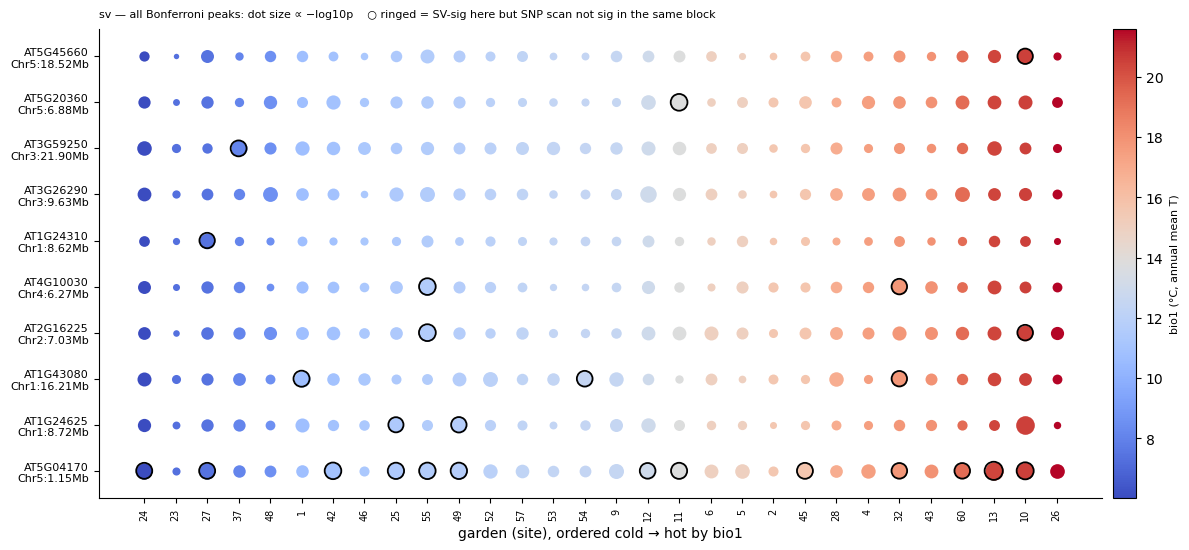

In [2]:

def recurrence(cls, D, rows_from="all"):
    """rows_from='all' -> every Bonferroni-significant class block (from A); 'new' -> SNP-blind only (from P).
    Ring is always the SNP-blind cell (class-sig AND SNP scan not sig in the same block, that garden)."""
    src = A if rows_from == "all" else P[P.bonf_new]
    s = src[src.cls == cls]
    if not len(s):
        print(f"(no {cls} peaks)"); return
    blocks = (s.groupby("block").agg(gene=("gene", "first"), chrom=("chrom", "first"),
              pos=("pos", "first"), n=("site", "nunique")).sort_values("n", ascending=False).reset_index())
    ring = P[(P.cls == cls) & (P.bonf_new)]              # SNP-blind cells (class-sig, SNPs non-sig)
    genuine = set(zip(ring.block, ring.site))
    lead = {}
    for _, b in blocks.iterrows():
        mask = D["blk"] == b.block
        lead[b.block] = {sid: (nlp_site(D, si)[mask].max() if mask.any() else 0.0) for si, sid in enumerate(sites)}
    fig, ax = plt.subplots(figsize=(12, 0.42 * len(blocks) + 1.4))
    for yi, (_, b) in enumerate(blocks.iterrows()):
        for sid in site_order:
            xi = xpos[sid]; v = lead[b.block][sid]
            ax.scatter(xi, yi, s=8 + v * 22, color=bio_color(sid), linewidths=0, zorder=2)
            if (b.block, sid) in genuine:
                ax.scatter(xi, yi, s=8 + v * 22, facecolors="none", edgecolors="k", linewidths=1.3, zorder=3)
    ax.set_yticks(range(len(blocks)))
    ax.set_yticklabels([f"{b.gene}\n{b.chrom}:{b.pos/1e6:.2f}Mb" for _, b in blocks.iterrows()], fontsize=8)
    ax.set_xticks(range(len(site_order))); ax.set_xticklabels([str(s) for s in site_order], fontsize=7, rotation=90)
    ax.set_xlabel("garden (site), ordered cold → hot by bio1"); ax.set_ylim(-0.6, len(blocks) - 0.4)
    lab = "all Bonferroni peaks" if rows_from == "all" else "SNP-blind peaks only"
    ax.annotate(f"{cls} — {lab}: dot size ∝ −log10p    ○ ringed = SV-sig here but SNP scan not sig in the same block",
                (0.0, 1.02), xycoords="axes fraction", fontsize=8, va="bottom")
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=BNORM, cmap=BIO_CMAP), ax=ax, pad=0.01, fraction=0.025)
    cb.set_label("bio1 (°C, annual mean T)", fontsize=8)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()

recurrence("sv", SV, rows_from="all")


### Non-SNP — SNP-blind peaks only (ring = SNP-blind)

The non-SNP class has far too many Bonferroni-significant blocks to show every peak as a row, so this
panel keeps **only the SNP-blind (novel) blocks** — every row here has ≥1 ringed cell. (The all-peaks
row set is feasible only for the sparse SV scan above.)

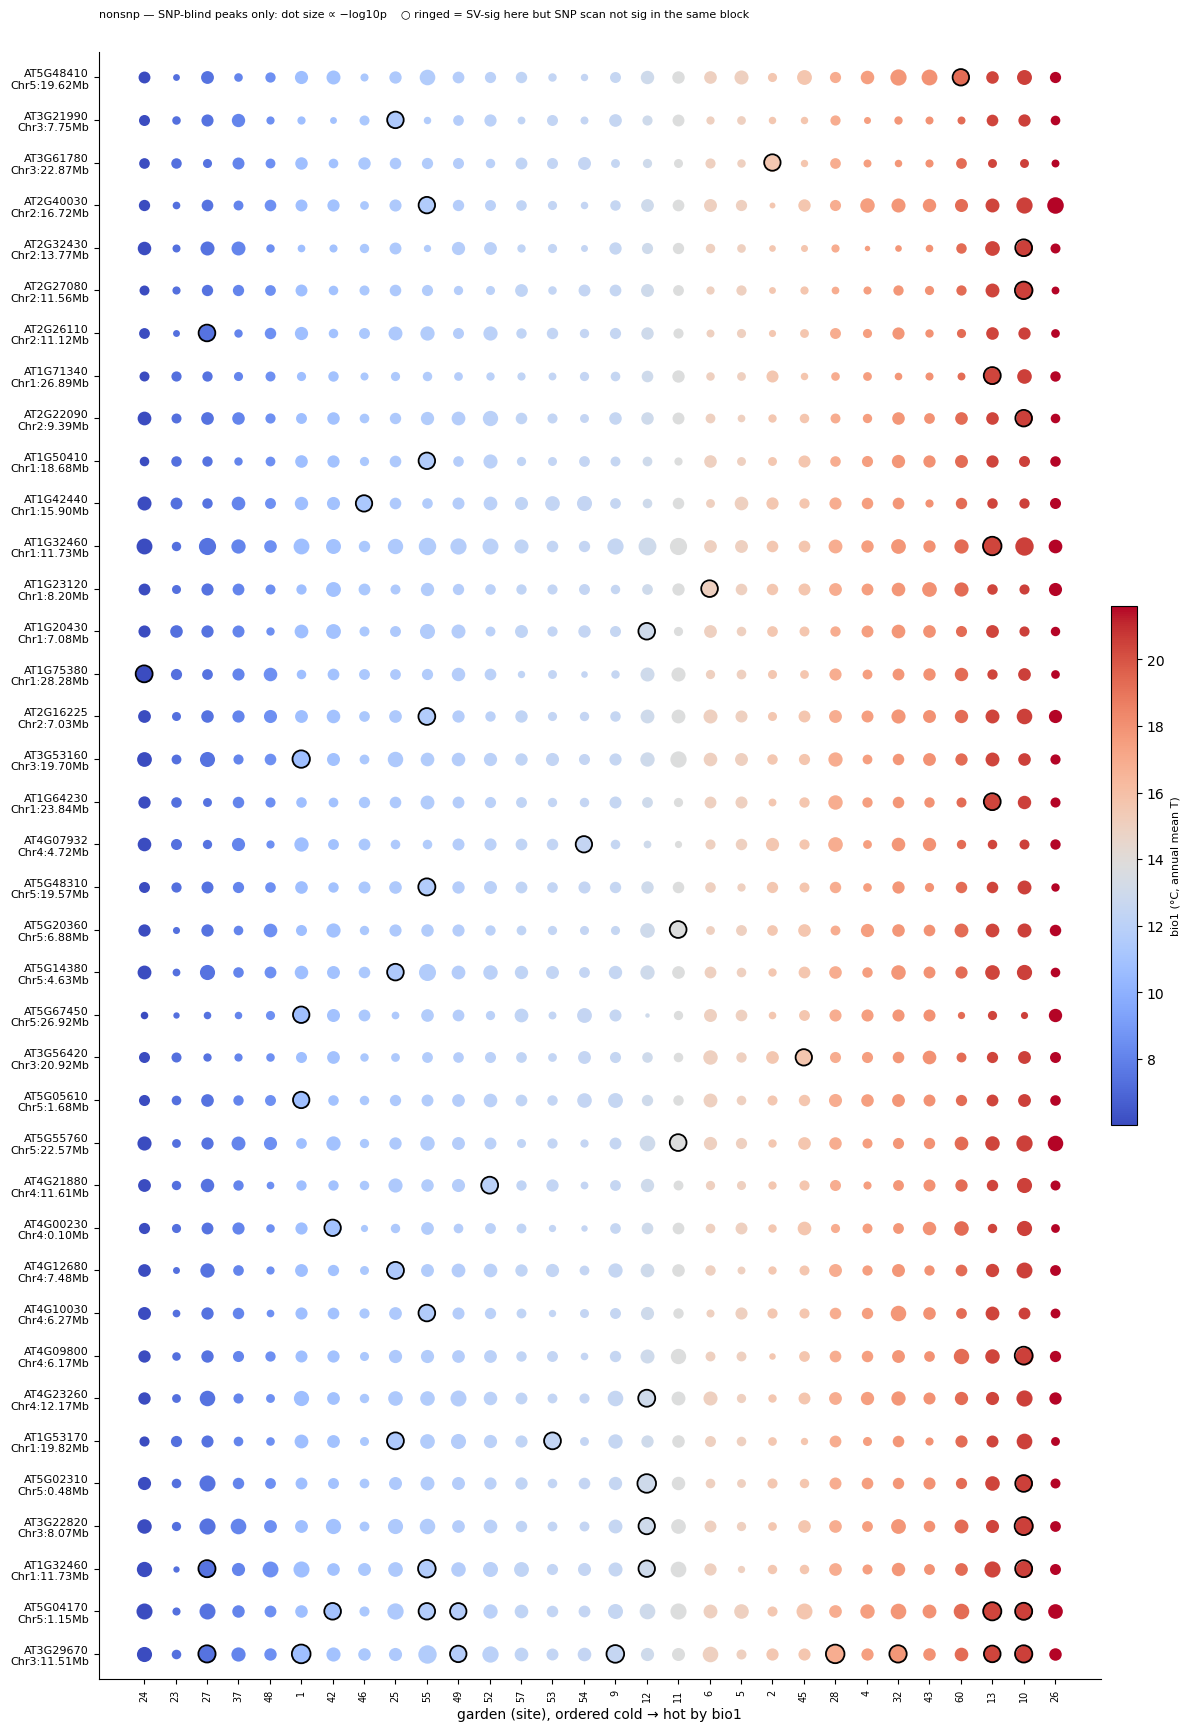

In [3]:
recurrence("nonsnp", NS, rows_from="new")

## 2. Per-garden mirror Manhattan — SNPs are low where the non-SNP peak is

For the gardens carrying the most genuine non-SNP new peaks: SNP −log10p **up**, non-SNP **down**,
shared genome axis. Grey dashed lines mark that garden's genuine (FDR) new peaks; gene labels on the
Bonferroni ones. **At the grey lines the SNP (up) side is low** — the honest "non-SNP peak where
SNPs are blind" view. Dashed horizontal lines = block-level Bonferroni per class.

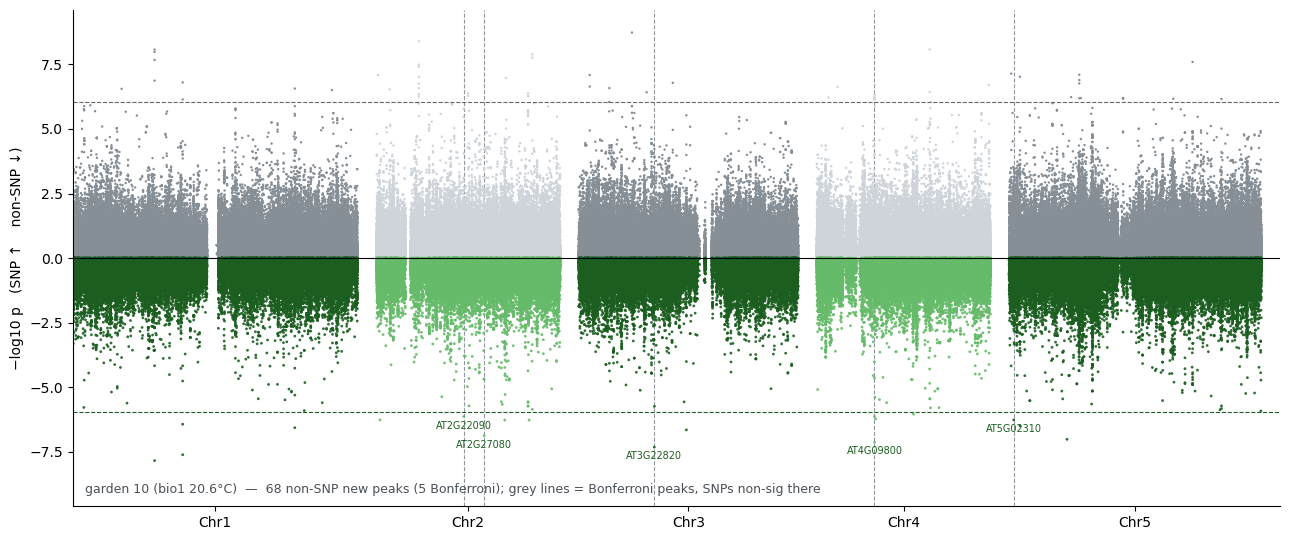

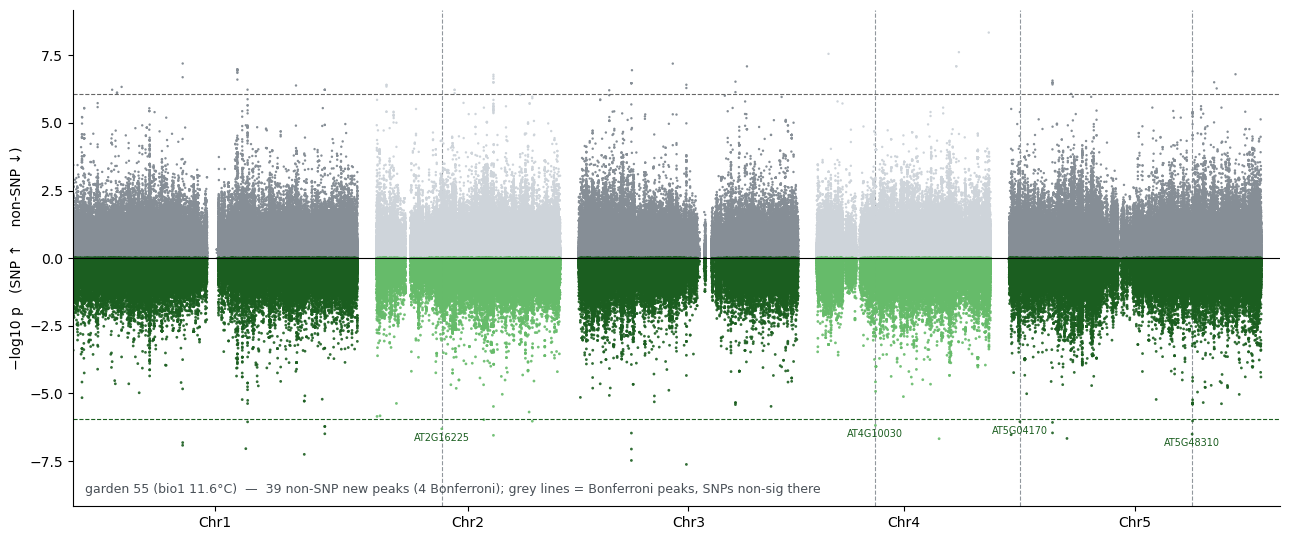

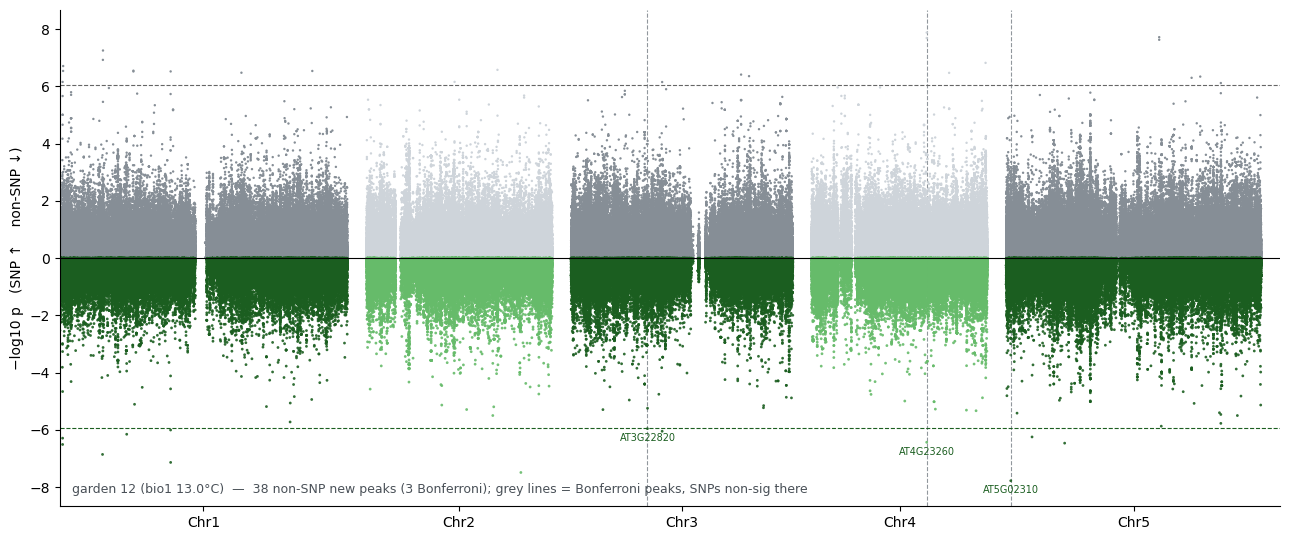

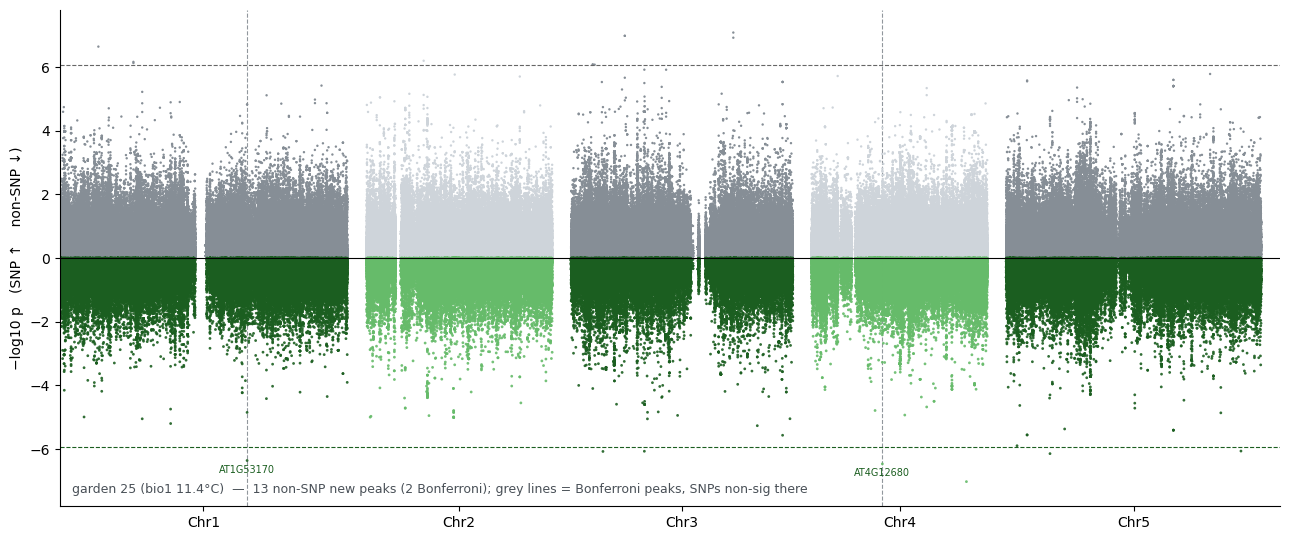

In [4]:

GARDENS = [10, 55, 12, 25]      # top gardens by genuine non-SNP new peaks
for g in GARDENS:
    si = sites.index(g); pk = P[(P.cls == "nonsnp") & (P.site == g) & (P.fdr_new)].copy()
    pk["gx"] = gx(pk.chrom.values, pk.pos.values)
    snl, nnl = nlp_site(SNP, si), nlp_site(NS, si)
    sgx, ngx = gx(SNP["chrom"], SNP["pos"]), gx(NS["chrom"], NS["pos"])
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for _, r in pk[pk.bonf_new].iterrows():        # vertical lines ONLY at Bonferroni new peaks
        ax.axvline(r.gx, color="#6c757d", lw=0.8, ls="--", alpha=0.75, zorder=0)
    ax.scatter(sgx, snl, s=3, c=[SNP_GREY[c] for c in SNP["chrom"]], rasterized=True, linewidths=0, zorder=2)
    ax.scatter(ngx, -nnl, s=4, c=[NS_GREEN[c] for c in NS["chrom"]], rasterized=True, linewidths=0, alpha=0.9, zorder=2)
    ax.axhline(BONF["snp"], ls="--", lw=.8, c="0.4"); ax.axhline(-BONF["nonsnp"], ls="--", lw=.8, c=GREEN_DK)
    ax.axhline(0, lw=.8, c="k")
    for _, r in pk[pk.bonf_new].iterrows():
        ax.annotate(r.gene, (r.gx, -r.cls_nlp), fontsize=7, ha="center", va="top",
                    xytext=(0, -3), textcoords="offset points", color=GREEN_DK, zorder=5)
    ax.set_xticks(ticks); ax.set_xticklabels(CHROM_ORDER)
    ax.set_ylabel("−log10 p   (SNP ↑    non-SNP ↓)")
    yl = max(snl.max(), nnl.max()) * 1.1; ax.set_xlim(0, cum); ax.set_ylim(-yl, yl)
    ax.annotate(f"garden {g} (bio1 {site_bio1[g]:.1f}°C)  —  {pk.block.nunique()} non-SNP new peaks "
                f"({int(pk.bonf_new.sum())} Bonferroni); grey lines = Bonferroni peaks, SNPs non-sig there",
                (0.01, 0.02), xycoords="axes fraction", fontsize=9, color="#495057", va="bottom")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()


## 3. Zoom loci — the strongest recurrent SV peaks

Top recurrent SV new-peaks in their strongest garden: local ±60 kb window, SNP (grey) vs SV
(terracotta) −log10p, gene models underneath, the SV lead ringed. SNPs flat, SV spiking.

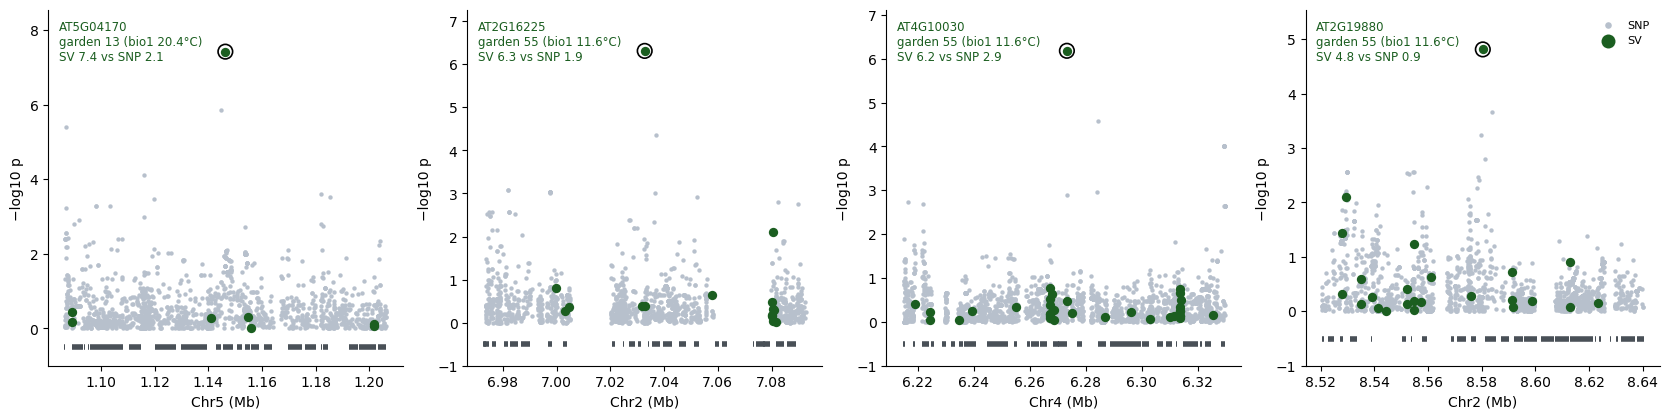

In [5]:

sv = P[(P.cls == "sv") & (P.fdr_new)]
top = (sv.groupby("block").agg(gene=("gene", "first"), chrom=("chrom", "first"),
       n=("site", "nunique")).sort_values("n", ascending=False).head(4).reset_index())
fig, axes = plt.subplots(1, len(top), figsize=(4.2 * len(top), 4.3), squeeze=False); axes = axes[0]
PAD = 60_000
for ax, (_, b) in zip(axes, top.iterrows()):
    best = sv[sv.block == b.block].sort_values("cls_nlp", ascending=False).iloc[0]
    si = sites.index(int(best.site)); c = b.chrom; center = int(best.pos); lo, hi = center - PAD, center + PAD
    for D, col, sz, z in [(SNP, SNPG, 10, 1), (SV, GREEN_DK, 45, 3)]:
        w = (D["chrom"] == c) & (D["pos"] >= lo) & (D["pos"] <= hi)
        ax.scatter(D["pos"][w] / 1e6, nlp_site(D, si)[w], s=sz, c=col, linewidths=0, zorder=z,
                   label="SNP" if col == SNPG else "SV")
    ax.scatter([center / 1e6], [best.cls_nlp], s=110, facecolors="none", edgecolors="k", linewidths=1.2, zorder=4)
    for _, gg in GENES[(GENES.chrom == c) & (GENES.start <= hi) & (GENES.end >= lo)].iterrows():
        ax.plot([max(gg.start, lo) / 1e6, min(gg.end, hi) / 1e6], [-0.5, -0.5], lw=4, c="#495057", solid_capstyle="butt")
    ax.set_xlabel(f"{c} (Mb)"); ax.set_ylabel("−log10 p"); ax.set_ylim(-1, max(best.cls_nlp, 3) * 1.15)
    ax.annotate(f"{b.gene}\ngarden {int(best.site)} (bio1 {site_bio1[int(best.site)]:.1f}°C)\nSV {best.cls_nlp:.1f} vs SNP {best.snp_nlp:.1f}",
                (0.03, 0.97), xycoords="axes fraction", ha="left", va="top", fontsize=8.5, color=GREEN_DK, zorder=5)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
axes[-1].legend(loc="upper right", frameon=False, markerscale=1.5, fontsize=8)
fig.tight_layout(); plt.show()


## Takeaway

At the **per-garden** level SVs/indels genuinely bring peaks the SNP scan misses — strong (gaps up
to ~5–7 −log10p), Bonferroni-level at several, and **recurrent across independent gardens** (not FDR
noise). Invisible to the aggregate SNP story because **garden-specific (local)** — consistent with
the polygenic/passenger result at the meta level. With gardens ordered by bio1, inspect whether the
ringed peaks concentrate at hot vs cold gardens (climate patterning) or spread evenly. Honest
framing: candidate **local-adaptation / incomplete-SNP-tagging** loci, not a genome-wide adaptive
layer (no GO enrichment). `AT5G04170`/CML50 (calcium sensor) is the standout recurrent SV peak.